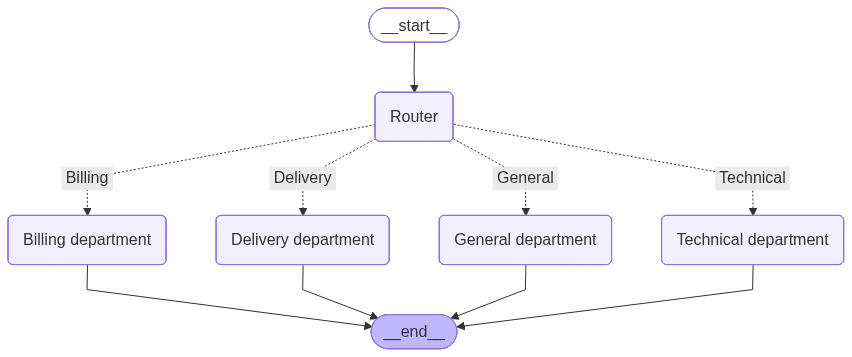

In [6]:
from langgraph.graph import StateGraph
from typing import TypedDict, Dict, Any, List
from IPython.display import display, Image

def router_node(state):
    return state

def billing(state):
    state['intent'] = 'Billing department'
    return state

def technical(state):
    state['intent'] = 'Technical department'
    return state

def delivery(state):
    state['intent'] = 'Delivery department'
    return state

def general(state):
    state['intent'] = 'General department'
    return state

def check_logic(state):
    msg = state['message'].lower()
    
    if 'refund' in msg or 'payment' in msg:
        return 'Billing'
    elif 'error' in msg or 'not working' in msg:
        return 'Technical'
    elif 'delayed' in msg or 'delivery' in msg:
        return 'Delivery'
    else:
        return 'General'
        
class intent_router(TypedDict):
    message: str
    intent: str

builder = StateGraph(intent_router)
builder.add_node('Router', router_node)
builder.add_node('Billing department', billing)
builder.add_node('Technical department', technical)
builder.add_node('Delivery department', delivery)
builder.add_node('General department', general)

builder.set_entry_point('Router')

builder.add_conditional_edges('Router',check_logic,
                              {
    'Billing':'Billing department',
    'Technical':'Technical department',
    'Delivery':'Delivery department',
    'General':'General department'
})

builder.set_finish_point('Billing department')
builder.set_finish_point('Technical department')
builder.set_finish_point('Delivery department')
builder.set_finish_point('General department')

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [8]:
input_text = 'My order was delayed'
result = graph.invoke({'message':input_text})
print(result['intent'])

Delivery department
